In [1]:
!pip install python-igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 30.9 MB/s eta 0:00:00


In [2]:
import igraph as ig
import numpy as np

N =100
m = 4

p = ((2*N-m-1)*m)/(N*(N-1))
d = []
for i in range(10000):
  g= ig.Graph.Erdos_Renyi(N, p=p)
  d.append(np.mean(g.degree()))
print(np.mean(d), np.std(d))

d = []
p = 2*m/(N-1)
for i in range(10000):
  g= ig.Graph.Erdos_Renyi(N, p=p)
  d.append(np.mean(g.degree()))
print(np.mean(d), np.std(d))

7.8016440000000005 0.37509638396550826
7.996726000000001 0.381125334928026


In [3]:
import igraph as ig
import numpy as np

N =10000
m = 3.5

p = ((2*N-m-1)*m)/(N*(N-1))
d = []
for i in range(10000):
  g = ig.Graph.Erdos_Renyi(N, p=p)
  d.append(np.mean(g.degree()))
print(np.mean(d), np.std(d))

d = []
p = 2*m/(N-1)
for i in range(10000):
  g = ig.Graph.Erdos_Renyi(N, p=p)
  d.append(np.mean(g.degree()))
print(np.mean(d), np.std(d))

KeyboardInterrupt: 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import curve_fit

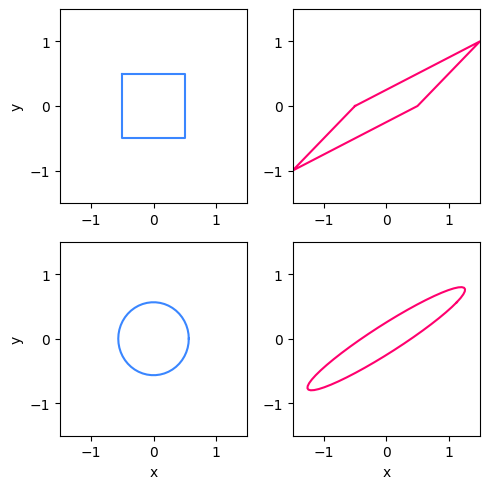

In [5]:
import numpy as np
import matplotlib.pyplot as plt

transform_mat = np.array([[2, 1], [1, 1]]) #simple transformation matrix

# Points for a square with unit area
square = np.array([[-.5, .5, .5, -.5, -.5], [.5, .5, -.5, -.5, .5]])
Strans = transform_mat@square

# Generating several points around the perimeter of a circle
r = np.sqrt(1 / np.pi)
theta = np.linspace(0, 2 * np.pi, 50, endpoint=False)
x = r * np.cos(theta)
y = r * np.sin(theta)
x = np.append(x, x[0])
y = np.append(y, y[0])

P = np.array([x, y])
Ctrans = transform_mat@P

# Plot the circle
plt.figure(figsize=(5, 5))
plt.subplot(2, 2, 1)
plt.plot(square[0, :], square[1, :], c='#3a86ff')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.ylabel('y')
plt.yticks([-1, 0, 1])
plt.subplot(2, 2, 2)
plt.plot(Strans[0, :], Strans[1, :], c='#ff006e')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.yticks([-1, 0, 1])
plt.subplot(2, 2, 3)
plt.plot(x, y, c='#3a86ff')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.xlabel('x')
plt.ylabel('y')
plt.yticks([-1, 0, 1])
plt.subplot(2, 2, 4)
plt.plot(Ctrans[0, :], Ctrans[1, :], c='#ff006e')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.xlabel('x')
plt.yticks([-1, 0, 1])
plt.tight_layout()
plt.savefig('FigTransform.pdf', format='pdf', bbox_inches='tight', pad_inches=0)


In [6]:
# 2D system
def mu1(qq, q_c, q_max, mu_max):
    # service rate that increases linearly until qq=q_c and then decreases until qq=q_jam
    # q_c is the capacity (congestion threshold) and q_max is the maximum qq
    if isinstance(qq, np.ndarray):
        return np.array([mu1(qItem, q_c, q_max, mu_max) for qItem in qq])
    else:
        if qq < q_c:
            muq = mu_max*qq/q_c
        elif qq <= q_max:
            muq = mu_max
        else:
            raise Exception("Queue overflow in MU function!!!")
        return muq

def f_fair2(qq, q_m, q_n, beta):
    if isinstance(qq, np.ndarray):
        return np.array([f_fair2(qItem, q_m, q_n, beta) for qItem in qq])
    else:
        if qq < q_m:
            leaveRate = beta * qq
        elif qq <= q_n:
            leaveRate = beta * (2*q_m-qq)
        else:
            leaveRate = beta * (2*q_m-q_n)
        return leaveRate

def f_surge(qq, beta):
    if isinstance(qq, np.ndarray):
        return np.array([f_surge(qItem, beta) for qItem in qq])
    else:
        return beta * qq

def alpha(x, alpha_params):
    return alpha_params[0]*x**3+alpha_params[1]*x**2+alpha_params[2]*x+alpha_params[3]

def dX_dt_surge(X, t, K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params):
    # X = [R, U, q]
    Rdot = K_R - f_surge(X[2], beta)*X[0] - alpha(X[2], alpha_params)*X[0]
    Udot = K_U - alpha(X[2], alpha_params)*X[1]
    qdot = alpha(X[2], alpha_params)*(X[0]+X[1]) - mu1(X[2], q_c, q_max, mu_max)
    return np.array([Rdot, Udot, qdot])

def dX_dt_fair(X, t, K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params):
    # X = [R, U, q]
    Rdot = K_R - f_fair2(X[2], q_m, q_n, beta)*X[0] - alpha(X[2], alpha_params)*X[0]
    Udot = K_U - alpha(X[2], alpha_params)*X[1]
    qdot = alpha(X[2], alpha_params)*(X[0]+X[1]) - mu1(X[2], q_c, q_max, mu_max)
    return np.array([Rdot, Udot, qdot])


0.03 0.005
0.07499999999999998 0.025


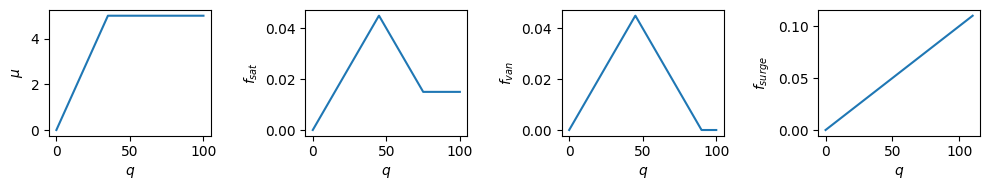

In [7]:
# PARAMETERS

# fixed points
q1, q2 = 30, 85

# Inherent System Params
K_R, K_U = 6, 2       # K > mu_star 8, 1
mu_max = 5
q_c, q_max = 35, 100       # q_max > 2*q_m

# Adjustable params #alpha(qStar1, a_slope, q_max) *
q_m, q_n = 45, 75
beta = 0.001

#if q2>= 2*q_m:
#    raise Exception("Second fixed point outside the domain of price function!")

p1, p2 = beta * q1,  beta * (2*q_m - q2)
mu_star1 = mu1(q1, q_c, q_max, mu_max) # mu* = mu(q*)
f_star1 = f_fair2(q1, q_m, q_n, beta) #f* = f(q*)
mu_star2 = mu1(q2, q_c, q_max, mu_max) # mu* = mu(q*)
f_star2 = f_fair2(q2, q_m, q_n, beta) #f* = f(q*)


alpha_star1 = (p1 * mu_star1)/(K_R - mu_star1)
alpha_star2 = (p2 * mu_star2)/(K_R - mu_star2)
alpha_slope = (alpha_star2-alpha_star1)/(q2-q1)
alpha_intcp = alpha_star1 - q1*alpha_slope
plt.figure(figsize=(10,2))
plt.subplot(1, 4, 1)
qs = np.linspace(0, q_max,  1000)
plt.plot(qs, mu1(qs, q_c, q_max, mu_max))
#plt.scatter([q1, q2], [mu_star1, mu_star2], c='red')
plt.xlabel(r'$q$')
plt.ylabel(r'$\mu$')
plt.subplot(1, 4, 2)
qs = np.linspace(0, q_max,  1000)
plt.plot(qs, f_fair2(qs, q_m, q_n, beta))
#plt.scatter([q1, q2], [f_star1, f_star2], c='red')
plt.xlabel(r'$q$')
plt.ylabel(r'$f_{sat}$')
plt.subplot(1, 4, 3)
qs = np.linspace(0, q_max,  1000)
plt.plot(qs, f_fair2(qs, q_m, 2*q_m, beta))
#plt.scatter([q1, q2], [f_star1, f_star2], c='red')
plt.xlabel(r'$q$')
plt.ylabel(r'$f_{van}$')
plt.subplot(1, 4, 4)
qs = np.linspace(0, q_max+10,  1000)
#plt.plot(qs, alpha(qs, alpha_slope, alpha_intcp, q_max))
#plt.scatter([q1, q2], [alpha_star1, alpha_star2], c='red')
plt.plot(qs, f_surge(qs, beta))
plt.xlabel(r'$q$')
plt.ylabel(r'$f_{surge}$')
plt.tight_layout()
print(p1, p2)
print(alpha_star1, alpha_star2)
#print((K_R-mu_star1)/p1, (K_R-mu_star2)/p2)
plt.savefig('f_func.pdf', format='pdf')
plt.show()

# **Find parameters of Alpha**

4.761904761904734e-09 -4.833333333333328e-06 -6.428571428571455e-05


/tmp/ipykernel_6285/624681390.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  (a,b,c,d), pcov = curve_fit(alpha_curve, x, y, p0=[0.001,0.001, 0, 0])


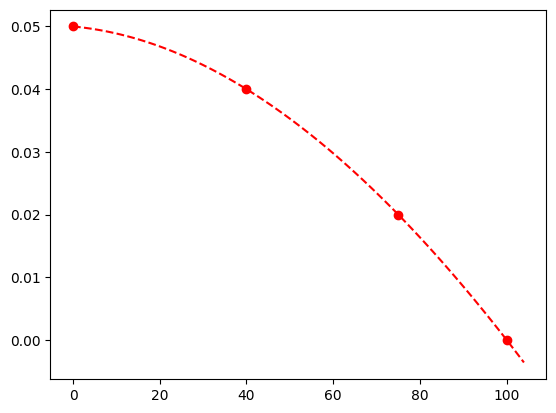

(np.float64(4.761904761904734e-09), np.float64(-4.833333333333328e-06), np.float64(-6.428571428571455e-05), np.float64(0.05))


In [8]:
def alpha_curve(x, a, b, c, d):
    return a*x**3+b*x**2+c*x+d

x = np.array([0, q1, q2, q_max])
y1 = f_fair2(q1, q_m, q_n, beta)*(mu1(q1, q_c, q_max, mu_max)-K_U)/(K_R-mu1(q1, q_c, q_max, mu_max)+K_U)
y2 = f_fair2(q2, q_m, q_n, beta)*(mu1(q2, q_c, q_max, mu_max)-K_U)/(K_R-mu1(q2, q_c, q_max, mu_max)+K_U)
y1 = f_fair2(q1, q_m, q_n, beta)*mu1(q1, q_c, q_max, mu_max)/(K_R-mu1(q1, q_c, q_max, mu_max))
y2 = f_fair2(q2, q_m, q_n, beta)*mu1(q2, q_c, q_max, mu_max)/(K_R-mu1(q2, q_c, q_max, mu_max))
y = np.array([0.035, y1, y2, 0])

x = np.array([0, 40, 70, q_max])
y = np.array([0.03, 0.023, 0.014, 0])

x = np.array([0, 40, 75, q_max])
y = np.array([0.05, 0.04, 0.02, 0])

(a,b,c,d), pcov = curve_fit(alpha_curve, x, y, p0=[0.001,0.001, 0, 0])
print(a, b, c)
xmodel = np.arange(105)             # Note: use numpy!
ymodel = alpha_curve(xmodel, a, b, c, d)  # Note: take exp() as inverse log()
fig, ax1 = plt.subplots()
ax1.plot(x, y, "ro", label="Experiment")
ax1.plot(xmodel,ymodel, "r--", label="Model")
plt.show()
alpha_params = (a,b,c,d)
print(alpha_params)

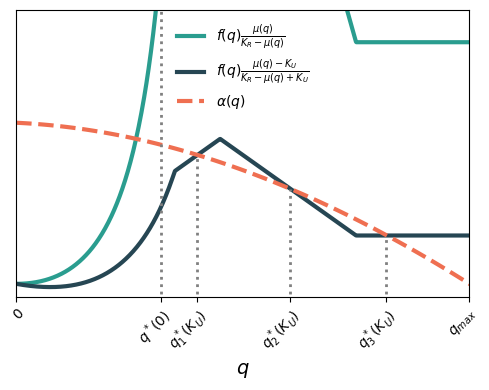

In [9]:
def alpha_curve(x, a, b, c, d):
    return a*x**3+b*x**2+c*x+d

def alpha_RHS(qqq):
    return f_fair2(qqq, q_m, q_n, beta)*(mu1(qqq, q_c, q_max, mu_max))/(K_R-mu1(qqq, q_c, q_max, mu_max))

def alpha_RHS2(qqq):
    return f_fair2(qqq, q_m, q_n, beta)*(mu1(qqq, q_c, q_max, mu_max)-K_U)/(K_R-mu1(qqq, q_c, q_max, mu_max)+K_U)

plt.figure(figsize=(5, 4))
#plt.plot(x, y, "ro", label="Experiment")
qs = np.linspace(0, q_max,  1000)
plt.plot(qs, alpha_RHS(qs), lw=3, color='#2a9d8f', label=r"$f(q)\frac{\mu(q)}{K_R-\mu(q)}$")
plt.plot(qs, alpha_RHS2(qs), lw=3, color='#264653', label=r"$f(q)\frac{\mu(q)-K_U}{K_R-\mu(q)+K_U}$")
ax1.plot(x, y, "ro", label="Experiment")
plt.xlabel(r'$q$', fontsize=14)
plt.ylabel(r'', fontsize=14)
xmodel = np.arange(105)            # Note: use numpy!
ymodel = alpha_curve(xmodel, a, b, c, d)  # Note: take exp() as inverse log()
plt.plot(xmodel,ymodel, lw=3, ls="--", color='#ef6f51', label=r"$\alpha(q)$")
q_1, q_2, q_3, q_4 = 32, 40, 60.5, 81.5
plt.plot([q_1, q_1],[-.01,alpha_RHS(q_1)], lw=2, ls=":", color='gray')
plt.plot([q_2, q_2],[-.01,alpha_RHS2(q_2)], lw=2, ls=":", color='gray')
plt.plot([q_3, q_3],[-.01,alpha_RHS2(q_3)], lw=2, ls=":", color='gray')
plt.plot([q_4, q_4],[-.01,alpha_RHS2(q_4)], lw=2, ls=":", color='gray')
plt.legend(frameon=False)
plt.xlim([0,100])
plt.ylim([-0.004,0.085])
plt.xticks([0, q_1, q_2, q_3, q_4, q_max], [0, r'$q^*(0)$', r'$q_1^*(K_U)$', r'$q_2^*(K_U)$', r'$q_3^*(K_U)$', r'$q_{max}$'], rotation=45, ha='right', rotation_mode='anchor')
plt.yticks([])
plt.tight_layout()
plt.savefig('schematic_saturated2.pdf', format='pdf')
plt.show()

# 2. Simulations

## 2.1 Timeseries plots (separate)

(0.0, 400.0)

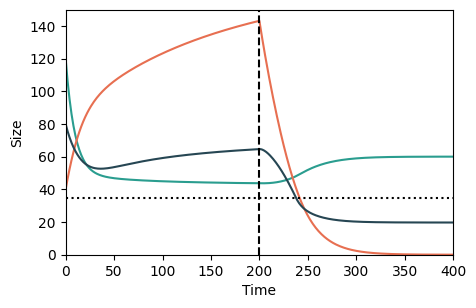

In [10]:
K_R, K_U = 4, 4
X_0 = np.array([120. , 40., 80.])
t_phase1 = np.linspace(0, 200,  200)              # time
#dX_dt_fair(X, t, K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params):
X_phase1 = integrate.odeint( dX_dt_surge, X_0, t_phase1, args=(K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t_phase2 = np.linspace(200, 1000,  800)              # time
X_phase2 = integrate.odeint( dX_dt_surge, X_phase1[-1], t_phase2, args=(K_R, 0, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t = np.concatenate((t_phase1, t_phase2), axis=0)

Xsurge = np.concatenate((X_phase1, X_phase2), axis=0)

plt.figure(figsize=(5, 7))
plt.subplot(2, 1, 1)
plt.plot(t, np.concatenate((X_phase1[:,0], X_phase2[:,0]), axis=0) , c='#2a9d8f',  label='R')
plt.plot(t, np.concatenate((X_phase1[:,1], X_phase2[:,1]), axis=0) , c='#e76f51', label='U')
plt.plot(t, np.concatenate((X_phase1[:,2], X_phase2[:,2]), axis=0), c='#264653', label='q')
plt.plot([200, 200], [0, 200], ls='--', c='k', label='U flow termination')
plt.plot([0, 1000], [q_c, q_c], ls=':', c='k', label=r'$q_c$')
#plt.plot(t, X[:,1], label='U')
#plt.plot(t, X[:,2], label='q')
plt.xlabel('Time')
plt.ylabel('Size')
plt.ylim([0, 150])
plt.xlim([0, 400])
#plt.legend(bbox_to_anchor=(1.05, 0.4))
#plt.legend(frameon=False)
#plt.savefig('timeseries_surge.pdf', format='pdf')

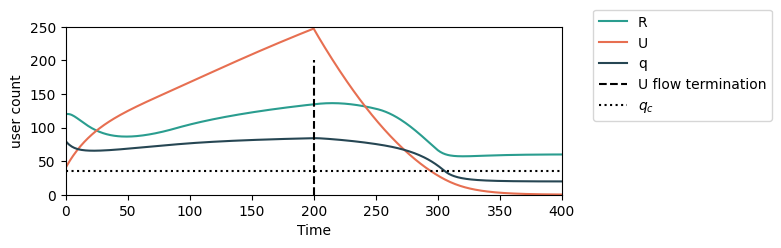

<Figure size 640x480 with 0 Axes>

In [11]:
#plt.figure()
X_0 = np.array([120. , 40., 80.])
t_phase1 = np.linspace(0, 200,  200)              # time
#dX_dt_fair(X, t, K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params):
X_phase1 = integrate.odeint( dX_dt_fair, X_0, t_phase1, args=(K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t_phase2 = np.linspace(200, 1000,  800)              # time
X_phase2 = integrate.odeint( dX_dt_fair, X_phase1[-1], t_phase2, args=(K_R, 0, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t = np.concatenate((t_phase1, t_phase2), axis=0)

Xfair = np.concatenate((X_phase1, X_phase2), axis=0)

#plt.figure(figsize=(5, 3))
plt.subplot(2, 1, 2)
plt.plot(t, np.concatenate((X_phase1[:,0], X_phase2[:,0]), axis=0) , c='#2a9d8f', label='R')
plt.plot(t, np.concatenate((X_phase1[:,1], X_phase2[:,1]), axis=0) , c='#e76f51', label='U')
plt.plot(t, np.concatenate((X_phase1[:,2], X_phase2[:,2]), axis=0) , c='#264653', label='q')
plt.plot([200, 200], [0, 200], ls='--', c='k', label='U flow termination')
plt.plot([0, 1000], [q_c, q_c], ls=':', c='k', label=r'$q_c$')
#plt.plot(t, X[:,1], label='U')
#plt.plot(t, X[:,2], label='q')
plt.xlabel('Time')
plt.ylabel('user count')
plt.ylim([0, 250])
plt.xlim([0, 400])
plt.legend(bbox_to_anchor=(1.05, 0.4))
plt.show()
plt.savefig('timeseries_fair.pdf', format='pdf')

## 2.2 Timeseries plots (merged)

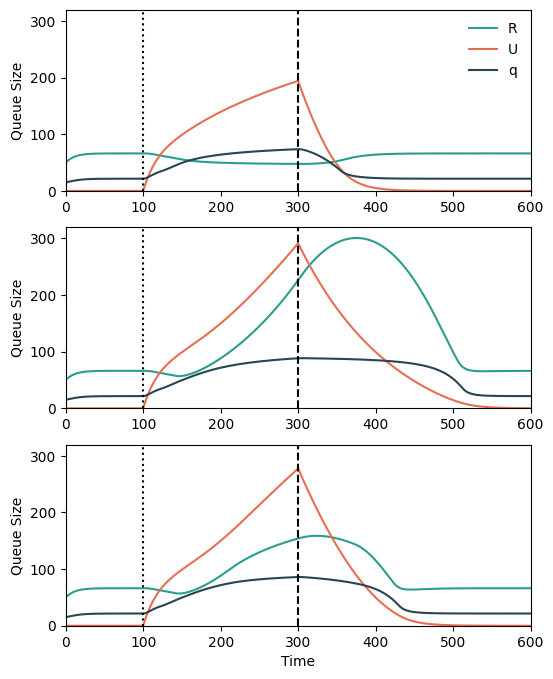

In [12]:
K_R, K_U = 4.5, 4.5
X_0 = np.array([50. , 0., 15.]) #100, 75, 90
t_phase0 = np.linspace(0, 100,  100)              # time
X_phase0 = integrate.odeint( dX_dt_surge, X_0, t_phase0, args=(K_R, 0, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t_phase1 = np.linspace(100, 300,  200)              # time
X_phase1 = integrate.odeint( dX_dt_surge, X_phase0[-1], t_phase1, args=(K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t_phase2 = np.linspace(300, 1000,  700)              # time
X_phase2 = integrate.odeint( dX_dt_surge, X_phase1[-1], t_phase2, args=(K_R, 0, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t = np.concatenate((t_phase0, t_phase1, t_phase2), axis=0)

Xsurge = np.concatenate((X_phase0, X_phase1, X_phase2), axis=0)

plt.figure(figsize=(6, 8))
plt.subplot(3, 1, 1)
plt.plot(t, Xsurge[:, 0] , c='#2a9d8f',  label='R')
plt.plot(t, Xsurge[:, 1] , c='#e76f51', label='U')
plt.plot(t, Xsurge[:, 2], c='#264653', label='q')
plt.plot([100, 100], [0, 400], ls=':', c='k')
plt.plot([300, 300], [0, 400], ls='--', c='k')
#plt.plot([0, 1000], [q_c, q_c], ls=':', c='k', label=r'$q_c$')
plt.legend(frameon=False)
plt.ylabel('Queue Size')
plt.ylim([0, 320])
plt.xlim([0, 600])

t_phase0 = np.linspace(0, 100,  100)              # time
X_phase0 = integrate.odeint( dX_dt_fair, X_0, t_phase0, args=(K_R, 0, q_c, q_max, mu_max, q_m, 2*q_m, beta, alpha_params))

t_phase1 = np.linspace(100, 300,  200)              # time
X_phase1 = integrate.odeint( dX_dt_fair, X_phase0[-1], t_phase1, args=(K_R, K_U, q_c, q_max, mu_max, q_m, 2*q_m, beta, alpha_params))

t_phase2 = np.linspace(300, 1000,  700)              # time
X_phase2 = integrate.odeint( dX_dt_fair, X_phase1[-1], t_phase2, args=(K_R, 0, q_c, q_max, mu_max, q_m, 2*q_m, beta, alpha_params))

t = np.concatenate((t_phase0, t_phase1, t_phase2), axis=0)

Xfair1 = np.concatenate((X_phase0, X_phase1, X_phase2), axis=0)


plt.subplot(3, 1, 2)
plt.plot(t, Xfair1[:, 0] , c='#2a9d8f', label='R')
plt.plot(t, Xfair1[:, 1] , c='#e76f51', label='U')
plt.plot(t, Xfair1[:, 2] , c='#264653', label='q')
plt.plot([100, 100], [0, 400], ls=':', c='k', label='U flow initiation')
plt.plot([300, 300], [0, 400], ls='--', c='k', label='U flow termination')
#plt.plot([0, 1000], [q_c, q_c], ls=':', c='k', label=r'$q_c$')
#plt.plot(t, X[:,1], label='U')
#plt.plot(t, X[:,2], label='q')
plt.ylabel('Queue Size')
plt.ylim([0, 320])
plt.xlim([0, 600])


t_phase0 = np.linspace(0, 100,  100)              # time
X_phase0 = integrate.odeint( dX_dt_fair, X_0, t_phase0, args=(K_R, 0, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t_phase1 = np.linspace(100, 300,  200)              # time
X_phase1 = integrate.odeint( dX_dt_fair, X_phase0[-1], t_phase1, args=(K_R, K_U, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t_phase2 = np.linspace(300, 1000,  700)              # time
X_phase2 = integrate.odeint( dX_dt_fair, X_phase1[-1], t_phase2, args=(K_R, 0, q_c, q_max, mu_max, q_m, q_n, beta, alpha_params))

t = np.concatenate((t_phase0, t_phase1, t_phase2), axis=0)

Xfair2 = np.concatenate((X_phase0, X_phase1, X_phase2), axis=0)


plt.subplot(3, 1, 3)
plt.plot(t, Xfair2[:, 0] , c='#2a9d8f', label='R')
plt.plot(t, Xfair2[:, 1] , c='#e76f51', label='U')
plt.plot(t, Xfair2[:, 2] , c='#264653', label='q')
plt.plot([100, 100], [0, 400], ls=':', c='k', label='U flow initiation')
plt.plot([300, 300], [0, 400], ls='--', c='k', label='U flow termination')
#plt.plot([0, 1000], [q_c, q_c], ls=':', c='k', label=r'$q_c$')
#plt.plot(t, X[:,1], label='U')
#plt.plot(t, X[:,2], label='q')
plt.xlabel('Time')
plt.ylabel('Queue Size')
plt.ylim([0, 320]) #plt.ylim([0, 190])
plt.xlim([0, 600])
#plt.legend(bbox_to_anchor=(1.05, 0.4))
plt.savefig('timeseries_merged.pdf', format='pdf')
plt.show()

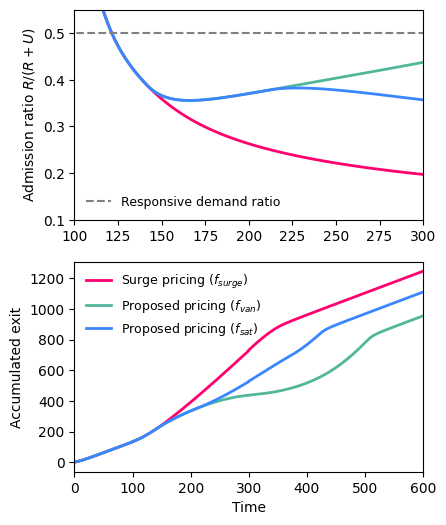

In [ ]:
plt.figure(figsize=(4.5, 6))
plt.subplot(2, 1, 1)
t_end = 300
plt.plot(t[:t_end], Xsurge[:t_end, 0]/(Xsurge[:t_end, 1]+Xsurge[:t_end, 0]), c='#ff006e', lw=2)
plt.plot(t[:t_end], Xfair1[:t_end, 0]/(Xfair1[:t_end, 1]+Xfair1[:t_end, 0]), c='#52b69a', lw=2)
plt.plot(t[:t_end], Xfair2[:t_end, 0]/(Xfair2[:t_end, 1]+Xfair2[:t_end, 0]), c='#3a86ff', lw=2)
plt.plot([-5, t_end], [K_R/(K_R+K_U), K_R/(K_R+K_U)], c='gray', ls='--', label=r'Responsive demand ratio')
plt.legend(frameon=False, fontsize=9)
plt.xlim([100, t_end])
plt.ylim([0.10, .55])
#plt.xlabel('Time')
plt.ylabel(r'Admission ratio $R/(R+U)$')
plt.subplot(2, 1, 2)
t_end = 600
plt.plot(t[:t_end], np.cumsum(f_surge(Xsurge[:t_end, 2], beta)*Xsurge[:t_end, 0]), c='#ff006e', lw=2, label='Surge pricing ($f_{surge}$)')
plt.plot(t[:t_end], np.cumsum(f_fair2(Xfair1[:t_end, 2], q_m, 2*q_m, beta)*Xfair1[:t_end, 0]), c='#52b69a', lw=2, label='Proposed pricing ($f_{van}$)')
plt.plot(t[:t_end], np.cumsum(f_fair2(Xfair2[:t_end, 2], q_m, q_n, beta)*Xfair2[:t_end, 0]), c='#3a86ff', lw=2, label='Proposed pricing ($f_{sat}$)')
#plt.plot([-5, t_end], [K_R/(K_R+K_U), K_R/(K_R+K_U)], c='gray', ls='--', label=r'Responsive demand ratio')
plt.legend(frameon=False, fontsize=9)
plt.xlim([0, t_end])
#plt.ylim([0.10, .55])
plt.xlabel('Time')
plt.ylabel(r'Accumulated exit')
plt.savefig('fairness.pdf', format='pdf')
plt.show()

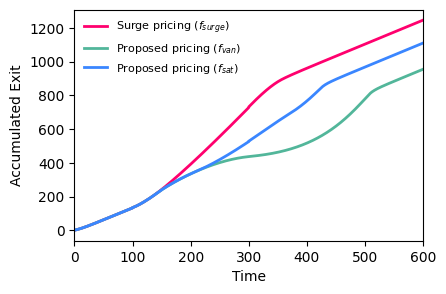

In [ ]:
plt.figure(figsize=(4.5, 3))
t_end = 600
plt.plot(t[:t_end], np.cumsum(f_surge(Xsurge[:t_end, 2], beta)*Xsurge[:t_end, 0]), c='#ff006e', lw=2, label='Surge pricing ($f_{surge}$)')
plt.plot(t[:t_end], np.cumsum(f_fair2(Xfair1[:t_end, 2], q_m, 2*q_m, beta)*Xfair1[:t_end, 0]), c='#52b69a', lw=2, label='Proposed pricing ($f_{van}$)')
plt.plot(t[:t_end], np.cumsum(f_fair2(Xfair2[:t_end, 2], q_m, q_n, beta)*Xfair2[:t_end, 0]), c='#3a86ff', lw=2, label='Proposed pricing ($f_{sat}$)')
#plt.plot([-5, t_end], [K_R/(K_R+K_U), K_R/(K_R+K_U)], c='gray', ls='--', label=r'Responsive demand ratio')
plt.legend(frameon=False, fontsize=8)
plt.xlim([0, t_end])
#plt.ylim([0.10, .55])
plt.xlabel('Time')
plt.ylabel(r'Accumulated Exit')
plt.savefig('fairness2.pdf', format='pdf')
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4206717102.py:21: SyntaxWarning: invalid escape sequence '\d'
  plt.text(100, 75, '$\dot{R}>0$\n$\dot{q}<0$')
/tmp/ipython-input-4206717102.py:22: SyntaxWarning: invalid escape sequence '\d'
  plt.text(800, 20, '$\dot{R}<0$\n$\dot{q}>0$')


NameError: name 'f_fair_3fixpts' is not defined

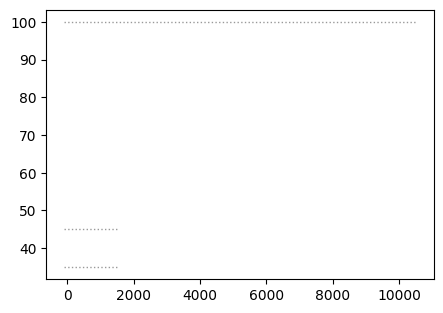

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.plot([-100, 10500], [q_max, q_max], ':k', lw=1, alpha=.4)
plt.plot([-100, 1500], [q_c, q_c], ':k', lw=1, alpha=.4)
plt.plot([-100, 1500], [q_m, q_m], ':k', lw=1, alpha=.4)

q_n = 80

qs = np.linspace(0, q_max, 501)
f_q = f_fair_3fixpts(qs, q_m, q_n, beta)
alpha_q = alpha(qs, alpha_slope, alpha_intcp, q2, q_max)
mu_q = mu1(qs, q_c, q_max, mu_max)

qs_hatch = np.linspace(q_m, q2, 500)
f_qh = f_fair_3fixpts(qs_hatch, q_m, q_n, beta)
alpha_qh = alpha(qs_hatch, alpha_slope, alpha_intcp, q2, q_max)
mu_qh = mu1(qs_hatch, q_c, q_max, mu_max)

plt.plot(K_R/(alpha_q+f_q), qs, c='#22B6BA', label=r'$\dot{R}=0$')
plt.plot(mu_q/alpha_q, qs, c='#EA6849', label=r'$\dot{q}=0$')
plt.fill_betweenx(qs_hatch, mu_qh/alpha_qh, K_R/(alpha_qh+f_qh), hatch='\\\\\\', edgecolor='#FCBC06', facecolor='#EECD64', alpha=0.3)#, label=r'$\mathcal{A}$')
plt.text(100, 75, '$\dot{R}>0$\n$\dot{q}<0$')
plt.text(800, 20, '$\dot{R}<0$\n$\dot{q}>0$')

# #print(K_R/(alpha_q+f_q))
# arbR, arbQ = 450, 68
# plt.plot([0, 0, K_R/(alpha_q[340]+f_q[340]), arbR, arbR, 0], [0, arbQ, qs[340], qs[290], 0, 0], c='gray', marker='o', markersize=5, alpha=0.7)
# plt.plot([K_R/(alpha_q[340]+f_q[340]), arbR, arbR], [qs[340], arbQ, qs[290]], c='gray', ls='--', alpha=0.7)
# plt.scatter([arbR], [arbQ], marker='x', s=30, c='b')
# print(qs[340])
# print(arbR)
# print(mu_q[290]/alpha_q[290], qs[290])
# plt.text(-15, -7, 'A', c='gray')
# plt.text(-30, arbQ+3, 'B', c='gray')
# plt.text(mu_q[290]/alpha_q[290]+30, arbQ-12, 'D', c='gray')
# plt.text(arbR-140, qs[340]+4, 'C', c='gray')
# plt.text(arbR-15, -7, 'E', c='gray')
# #plt.scatter([0, 0, ])

plt.xlabel('R')
plt.ylabel('q')
plt.yticks([0, q_m, q_c, 100], [0, r'$q_m$', r'$q_c$', r'$q_{max}$'])
plt.xticks([0, K_R/(alpha_q[0]+f_q[0])], [0, r'$K/\alpha(0)$'])
plt.xlim([-5, 1300])
plt.ylim([-10, 105])
plt.legend(fontsize=8, ncol=3, frameon=False)
plt.savefig('attraction.pdf', format='pdf')
plt.show()

0.0


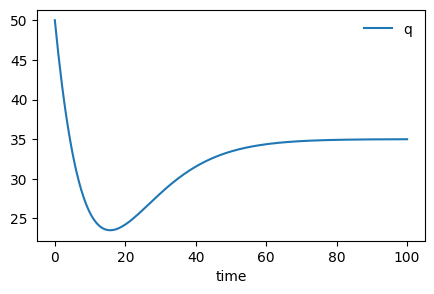

In [ ]:
# q1, q2 = 30, 65

# K_R = 17          # K > mu_star
# mu_max = 5
# q_c, q_max = 45, 100       # q_max > 2*q_m

# q_m = 40
# beta = .001

# if q2>= 2*q_m:
#     raise Exception("Second fixed point outside the domain of price function!")

# p1, p2 = beta * q1,  beta * (2*q_m - q2)
# mu_star1 = mu1(q1, q_c, q_max, mu_max) # mu* = mu(q*)
# f_star1 = f_fair1(q1, q_m, beta) #f* = f(q*)
# mu_star2 = mu1(q2, q_c, q_max, mu_max) # mu* = mu(q*)
# f_star2 = f_fair1(q2, q_m, beta) #f* = f(q*)


# alpha_star1 = (p1 * mu_star1)/(K_R - mu_star1)
# alpha_star2 = (p2 * mu_star2)/(K_R - mu_star2)
# alpha_slope = (alpha_star2-alpha_star1)/(q2-q1)
# alpha_intcp = alpha_star1 - q1*alpha_slope
print(mu1(0, q_c, q_max, mu_max)/alpha(0, alpha_slope, alpha_intcp, q_max))
X_0 = np.array([0 , 50.])
t = np.linspace(0, 100,  200)              # time
X_vs_t = integrate.odeint( dX_dt, X_0, t, args=(q_c, q_max, mu_max, q_m, beta, alpha_slope, alpha_intcp))

plt.figure(figsize=(5, 3))
#plt.plot(t, X_vs_t[:, 0], label='R')
plt.plot(t, X_vs_t[:, 1], label='q')
#plt.plot([0, 500], [35, 35], ls=':', c='k', label=r'$q_c$')
plt.xlabel('time')
#plt.ylim([0, 150])
#plt.xlim([0, 300])
plt.legend(frameon=False)

In [ ]:
# System definition
def mu(qq, q_c, q_max, mu_max):
    # service rate that increases linearly until qq=q_c and then decreases until qq=q_jam
    # q_c is the capacity (congestion threshold) and q_max is the maximum qq
    if isinstance(qq, np.ndarray):
        return np.array([mu(qItem, q_c, q_max, mu_max) for qItem in qq])
    else:
        if qq < q_c:
            muq = mu_max*qq/q_c
        elif qq <= q_max:
            muq = mu_max*(q_max-qq)/(q_max-q_c)
        else:
            muq = 0
        return muq


def price1(qq, beta, q_m, q_max):
    # SURGE PRICING for entering the service
    if isinstance(qq, np.ndarray):
        return np.array([price1(qItem, beta, q_m, q_max) for qItem in qq])
    else:
        if 0 <= qq <= q_max:
            return beta*qq
        else:
            raise Exception("Queue overflow!!!")

def price2(qq, beta, q_m, q_max):
    # FAIR PRICING for entering the service
    if isinstance(qq, np.ndarray):
        return np.array([price2(qItem, beta, q_m, q_max) for qItem in qq])
    else:
        if 0 <= qq < q_m:
            return beta*qq
        elif q_m <= qq <= q_max:
            return (beta*q_m) * (q_max-qq)/(q_max-q_m)
        elif q_max<= qq:
            return 0
        else:
            raise Exception("Queue overflow!!!")

def f(p):
    # response rate of R class to price
    return 100*p**2

def alpha(qq, a_slope, q_max):
    # Gate from Waiting to Service queue
    if isinstance(qq, np.ndarray):
        return np.array([alpha(qItem, a_slope, q_max) for qItem in qq])
    else:
        return (0.7*q_max-qq)*a_slope if 0<=qq<=0.7*q_max else 0


def dX_dt(X, t, q_c, q_max, mu_max, q_m, beta, a_slope):
    # X = [R, U, q]
    Rdot = K_R - f(price2(X[2], beta, q_m, q_max))*X[0] - alpha(X[2], a_slope, q_max)*X[0]
    Udot = K_U - alpha(X[2], a_slope, q_max)*X[1]
    qdot = alpha(X[2], a_slope, q_max)*(X[0] + X[1]) - mu(X[2], q_c, q_max, mu_max)
    return np.array([Rdot, Udot, qdot])

def dX_dt_ZU(X, t, q_c, q_max, mu_max, q_m, beta, a_slope):
    # X = [R, U, q]
    Rdot = K_R - f(price2(X[2], beta, q_m, q_max))*X[0] - alpha(X[2], a_slope, q_max)*X[0]
    Udot = - alpha(X[2], a_slope, q_max)*X[1]
    qdot = alpha(X[2], a_slope, q_max)*(X[0] + X[1]) - mu(X[2], q_c, q_max, mu_max)
    return np.array([Rdot, Udot, qdot])

alpha(q*)= 0.13909090909090907 ,


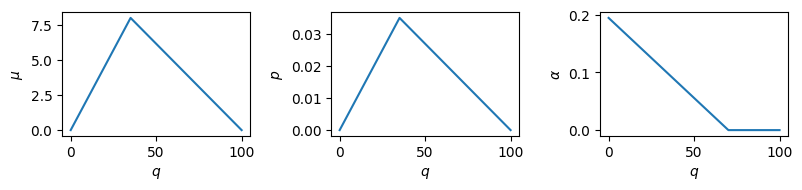

In [ ]:
# PARAMETERS

# Choose the first fixed point
qStar1 = 30

# Inherent System Params
K_R, K_U = 8, 2            # arrival rate 10, 2
mu_max = 8
q_c, q_max = 35, 100

# Adjustable params #alpha(qStar1, a_slope, q_max) *
q_m = 35
beta = .001

####################################################
#print((mu_star*f_star-K_U)/(K_R-mu_star))
#print(((mu_star - K_U)*f_star)/(K_R + K_U - mu_star ))

# alpha* = (mu* * f* - KU)/(KR-mu*)
# alpha* = ((mu* - K_U)*f*)/(K_R + K_U - mu*)
#####################################################

mu_star = mu(qStar1, q_c, q_max, mu_max) # mu* = mu(q*)
f_star = f(price2(qStar1, beta, q_m, q_max)) #f* = f(p(q*))
alpha_star = ((mu_star - K_U)*f_star)/(K_R + K_U - mu_star )
alpha_slope = alpha_star / (0.8*q_max - qStar1) # alpha is a linearly decreasing function in q\in[0, q_max] with alpha(qmax)=0
(mu(qStar1, q_c, q_max, mu_max)-K_U) /alpha(qStar1, alpha_slope, q_max)
print('alpha(q*)=', alpha_star,',')
plt.figure(figsize=(8,2))
plt.subplot(1, 3, 1)
qs = np.linspace(0, q_max,  1000)
plt.plot(qs, mu(qs, q_c, q_max, mu_max))
plt.xlabel(r'$q$')
plt.ylabel(r'$\mu$')
plt.subplot(1, 3, 2)
qs = np.linspace(0, q_max,  1000)
plt.plot(qs, price2(qs, beta, q_m, q_max))
plt.xlabel(r'$q$')
plt.ylabel(r'$p$')
plt.subplot(1, 3, 3)
qs = np.linspace(0, q_max,  1000)
plt.plot(qs, alpha(qs, alpha_slope, q_max))
plt.xlabel(r'$q$')
plt.ylabel(r'$\alpha$')
plt.tight_layout()
plt.savefig('parameters.pdf', format='pdf')
plt.show()


<Figure size 640x480 with 0 Axes>

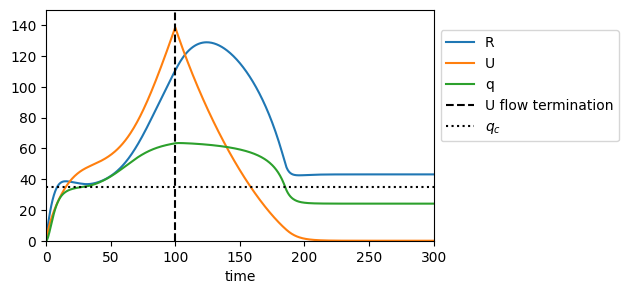

In [ ]:
K_U = 5
plt.figure()
X_0 = np.array([0. , 0., 0.]) #fixed_points
t2 = np.linspace(0, 100,  200)              # time
X2 = integrate.odeint( dX_dt, X_0, t2, args=(q_c, q_max, mu_max, q_m, beta, alpha_slope))
tz2 = np.linspace(100, 500,  800)              # time
XZ2 = integrate.odeint( dX_dt_ZU, X2[-1, :], tz2, args=(q_c, q_max, mu_max, q_m, beta, alpha_slope))
plt.figure(figsize=(5, 3))
plt.plot(np.concatenate((t2, tz2), axis=0), np.concatenate((X2[:,0], XZ2[:,0]), axis=0) , label='R')
plt.plot(np.concatenate((t2, tz2), axis=0), np.concatenate((X2[:,1], XZ2[:,1]), axis=0) , label='U')
plt.plot(np.concatenate((t2, tz2), axis=0), np.concatenate((X2[:,2], XZ2[:,2]), axis=0) , label='q')
plt.plot([100, 100], [0, 200], ls='--', c='k', label='U flow termination')
plt.plot([0, 500], [35, 35], ls=':', c='k', label=r'$q_c$')
#plt.plot(t, X[:,1], label='U')
#plt.plot(t, X[:,2], label='q')
plt.xlabel('time')
plt.ylim([0, 150])
plt.xlim([0, 300])
plt.legend(bbox_to_anchor=(1, 0.4))
#print(X[-1, :])
plt.savefig('timeseries1.pdf', format='pdf')

NameError: name 'RR1' is not defined

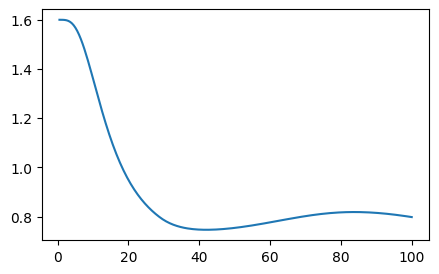

In [ ]:
from typing_extensions import Required
tt = np.concatenate((t2, tz2), axis=0)
RR2 = np.concatenate((X2[:,0], XZ2[:,0]), axis=0)
UU2 = np.concatenate((X2[:,1], XZ2[:,1]), axis=0)
qq2 = np.concatenate((X2[:,2], XZ2[:,2]), axis=0)
kkr = K_R*np.ones(tt.size)
kku = [K_U]*200 + [0] * 800
#plt.plot(tt, np.cumsum(XX*f(price2(XX, beta, q_m, q_max)))*0.5)
#plt.plot(tt, np.cumsum(XX*alpha(qq, alpha_slope, q_max))*0.5)
#plt.plot(tt, (np.cumsum(XX*alpha(qq, alpha_slope, q_max))*0.5)/(np.cumsum(kkr)*0.5))
#plt.plot(tt, (np.cumsum(RR*alpha(qq1, alpha_slope, q_max))*0.5)/(np.cumsum(kkr)*0.5))
#plt.plot(tt, (np.cumsum(UU*alpha(qq, alpha_slope, q_max))*0.5)/(np.cumsum(kku)*0.5))
plt.figure(figsize=(5, 3))
plt.plot(tt[1:200], np.divide(RR2[1:200],UU2[1:200]), label='our system')
plt.plot(tt[1:200], np.divide(RR1[1:200],UU1[1:200]), ls='--', label='surge pricing')
plt.xlabel('time')
plt.ylabel('R/U admittance ratio')
plt.legend()

In [ ]:
tt = np.concatenate((t, tz), axis=0)
RR1 = np.concatenate((X[:,0], XZ[:,0]), axis=0)
UU1 = np.concatenate((X[:,1], XZ[:,1]), axis=0)
qq1 = np.concatenate((X[:,2], XZ[:,2]), axis=0)
kkr = K_R*np.ones(tt.size)
kku = [K_U]*200 + [0] * 800
#plt.plot(tt, np.cumsum(XX*f(price2(XX, beta, q_m, q_max)))*0.5)
#plt.plot(tt, np.cumsum(XX*alpha(qq, alpha_slope, q_max))*0.5)
plt.plot(tt, (np.cumsum(RR*alpha(qq1, alpha_slope, q_max))*0.5)/(np.cumsum(kkr)*0.5))
plt.plot(tt, (np.cumsum(UU*alpha(qq1, alpha_slope, q_max))*0.5)/(np.cumsum(kku)*0.5))

NameError: name 't' is not defined

[30.35420538 65.94820298 43.92918832]


<Figure size 640x480 with 0 Axes>

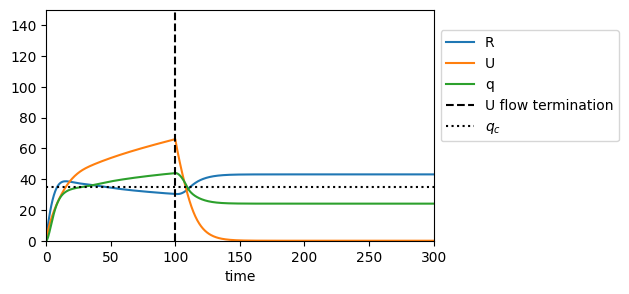

In [ ]:
K_U = 5
plt.figure()
X_0 = np.array([0. , 0., 0.]) #fixed_points
t = np.linspace(0, 100,  200)              # time
X = integrate.odeint( dX_dt, X_0, t, args=(q_c, q_max, mu_max, q_m, beta, alpha_slope))
tz = np.linspace(100, 500,  800)              # time
XZ = integrate.odeint( dX_dt_ZU, X[-1, :], tz, args=(q_c, q_max, mu_max, q_m, beta, alpha_slope))
plt.figure(figsize=(5, 3))
plt.plot(np.concatenate((t, tz), axis=0), np.concatenate((X[:,0], XZ[:,0]), axis=0) , label='R')
plt.plot(np.concatenate((t, tz), axis=0), np.concatenate((X[:,1], XZ[:,1]), axis=0) , label='U')
plt.plot(np.concatenate((t, tz), axis=0), np.concatenate((X[:,2], XZ[:,2]), axis=0) , label='q')
plt.plot([100, 100], [0, 200], ls='--', c='k', label='U flow termination')
plt.plot([0, 500], [35, 35], ls=':', c='k', label=r'$q_c$')
#plt.plot(t, X[:,1], label='U')
#plt.plot(t, X[:,2], label='q')
plt.xlabel('time')
plt.ylim([0, 150])
plt.xlim([0, 300])
plt.legend(bbox_to_anchor=(1, 0.4))
print(X[-1, :])
plt.savefig('timeseries1.pdf', format='pdf')

[ 1.3968254   3.76068376 30.        ]


<Figure size 640x480 with 0 Axes>

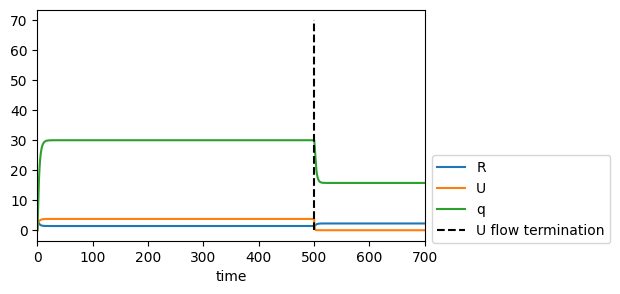

In [ ]:
plt.figure()
X_0 = np.array([0. , 0., 0.]) #fixed_points
t = np.linspace(0, 500,  1000)              # time
X = integrate.odeint( dX_dt, X_0, t, args=(q_c, q_max, mu_max, q_m, beta, alpha_slope))
tz = np.linspace(500, 700,  400)              # time
XZ = integrate.odeint( dX_dt_ZU, X[-1, :], tz, args=(q_c, q_max, mu_max, q_m, beta, alpha_slope))
plt.figure(figsize=(5, 3))
plt.plot(np.concatenate((t, tz), axis=0), np.concatenate((X[:,0], XZ[:,0]), axis=0) , label='R')
plt.plot(np.concatenate((t, tz), axis=0), np.concatenate((X[:,1], XZ[:,1]), axis=0) , label='U')
plt.plot(np.concatenate((t, tz), axis=0), np.concatenate((X[:,2], XZ[:,2]), axis=0) , label='q')
plt.plot([500, 500], [0, 70], ls='--', c='k', label='U flow termination')
#plt.plot(t, X[:,1], label='U')
#plt.plot(t, X[:,2], label='q')
plt.xlabel('time')
#plt.ylim([0, 70])
plt.xlim([0, 700])
plt.legend(bbox_to_anchor=(1, 0.4))
print(X[-1, :])
plt.savefig('timeseries1.pdf', format='pdf')